# Leave-one-out $\lambda_m$ and $\rho_m$

Perfect-model skill from each member against the mean of the others. For every grid cell
and every member $n$, with $s_{-n}$ the ensemble mean over the other $N-1$ members:

$$I_n = I\big(f_n;s_{-n}\big),\quad
\lambda_m = \frac1N\sum_n \sqrt{1-2^{-2I_n}},\qquad
\rho_m = \frac1N\sum_n \mathrm{corr}\big(f_n,s_{-n}\big)$$

$\lambda$ is formed per member and *then* averaged; averaging $I_n$ first and transforming
once gives a different, larger number. MI comes from `infomeasure`'s KSG estimator via
`scripts/infomeasure_rpc.py` (bits, `noise_level=0`, max norm, rank/copula transform,
$k=5$).

Both are computed on the data as it comes and on month-of-year anomalies, since the
preprocessing removes a linear trend but no seasonal cycle.

**Handles**

| name | shape | meaning |
|---|---|---|
| `I_N[t]` | `(49, 64, 128)` | $I_n$ in bits, per member |
| `LAM_N[t]` | `(49, 64, 128)` | $\lambda_n$, per member |
| `LAM_M[t]` | `(64, 128)` | $\lambda_m$ |
| `R_N[t]` | `(49, 64, 128)` | $r_n$, per member |
| `RHO_M[t]` | `(64, 128)` | $\rho_m$ |
| `rho_m_var` | `(64, 128)` | published variance-based $\rho_m$, for reference |

`t` is one of `TREATMENTS`; `panel(ax, field, cmap, norm, title)` draws a map.

In [1]:
import os
import sys
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.colors import Normalize
import cartopy.crs as ccrs

sys.path.insert(0, "../scripts")
import infomeasure_rpc as R

rc('font', **{'family': 'sans-serif', 'serif': ['Helvetica']})
rc('text', usetex=False)

DATA = "../data" if os.path.isdir("../data/ensembles") else \
    "/Users/jasperchen/Academics/Research/SNP/information-snp/data"
f, s, obs = R.load_data(data_dir=DATA)
lats, lons = f["lat"].to_numpy(), f["lon"].to_numpy()
rho_m_var = R.var_RPC(f, s, obs)[1].to_numpy()

PROJ = ccrs.PlateCarree()
LON180 = ((lons + 180) % 360) - 180        # grid is 0..357E; roll to -180..180
ORDER = np.argsort(LON180)
EXTENT = [LON180[ORDER].min(), LON180[ORDER].max(), lats.min(), lats.max()]


def panel(ax, field, cmap, norm, title):
    ax.set_global()
    h = ax.imshow(field[:, ORDER], origin="lower", extent=EXTENT, transform=PROJ,
                  cmap=cmap, norm=norm)
    ax.coastlines(linewidth=0.4, color="0.6")
    ax.set_title(title, fontsize=9)
    return h

/Users/jasperchen/Academics/Research/SNP/information-snp/.venv/lib/python3.13/site-packages/xarray/core/nputils.py:242: RuntimeWarning: Degrees of freedom <= 0 for slice.
  result = getattr(npmodule, name)(values, axis=axis, **kwargs)


## Leave-one-out means

`loo_mean(n)` returns $s_{-n}$ as a `(T, lat, lon)` field, built from the total nan-aware
sum and count rather than 49 separate `nanmean` calls -- exact, and avoids a second copy
of the ensemble.

In [2]:
F = f.psl.to_numpy()                       # (N, T, lat, lon), NaNs intact
N, T = F.shape[:2]
_valid = ~np.isnan(F)
_sum = np.nansum(F, axis=0)
_count = _valid.sum(axis=0)
month = np.arange(T) % 12


def loo_mean(n):
    """Ensemble mean excluding member n: nan-aware, then zero-filled."""
    num = _sum - np.where(_valid[n], F[n], 0.0)
    den = _count - _valid[n]
    return np.nan_to_num(np.where(den > 0, num / np.maximum(den, 1), np.nan), nan=0.0)


def deseason(a):
    """Subtract the month-of-year climatology along the time axis."""
    out = a.copy()
    for m in range(12):
        sel = month == m
        out[sel] = a[sel] - a[sel].mean(axis=0, keepdims=True)
    return out


def pair(n, treatment):
    """(f_n, s_-n) ready for an estimator, both (T, lat, lon)."""
    f_n, s_n = np.nan_to_num(F[n], nan=0.0), loo_mean(n)
    return (deseason(f_n), deseason(s_n)) if treatment == "deseasonalised" else (f_n, s_n)


with warnings.catch_warnings():                            # loo_mean is exact
    warnings.simplefilter("ignore", RuntimeWarning)
    for _n in (0, 12, 48):
        _d = np.nan_to_num(np.nanmean(np.delete(F[:, :, 32, 21], _n, axis=0), axis=0), nan=0.0)
        assert np.allclose(loo_mean(_n)[:, 32, 21], _d)

## $\lambda_m$

One KSG call per member per grid cell, $49\times64\times128$ of them. A cold run of both
treatments takes about eight minutes, so it is cached.

In [3]:
CACHE = "../data/granger_lin_cache.npz"
TREATMENTS = ["as-is", "deseasonalised"]
K = 5


def lam(I):
    """sqrt(1 - 2^-2I), argument of the sqrt clamped at 0."""
    return np.sqrt(np.maximum(0.0, 1.0 - 2.0 ** (-2.0 * I)))


def loo_mi(treatment):
    """I(f_n ; s_-n) for every member and grid cell, shape (N, lat, lon)."""
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        f_n, s_n = pair(n, treatment)
        for la in range(F.shape[2]):
            for lo in range(F.shape[3]):
                out[n, la, lo] = R.mi_bits(f_n[:, la, lo], s_n[:, la, lo], "ksg", param=K)
    return out


if os.path.exists(CACHE):
    _z = np.load(CACHE)
    I_N = {t: _z[t] for t in TREATMENTS}
else:
    I_N = {t: loo_mi(t) for t in TREATMENTS}
    np.savez_compressed(CACHE, **I_N)

LAM_N = {t: lam(I_N[t]) for t in TREATMENTS}              # (N, lat, lon)
LAM_M = {t: LAM_N[t].mean(axis=0) for t in TREATMENTS}    # (lat, lon)

## $\rho_m$

Same construction, Pearson correlation instead of MI. Vectorised over the grid, so this is
seconds and needs no cache.

In [4]:
def loo_pearson(treatment):
    """corr(f_n, s_-n) for every member and grid cell, shape (N, lat, lon)."""
    out = np.empty((N,) + F.shape[2:])
    for n in range(N):
        f_n, s_n = pair(n, treatment)
        a = f_n - f_n.mean(axis=0, keepdims=True)
        b = s_n - s_n.mean(axis=0, keepdims=True)
        den = np.sqrt((a ** 2).sum(axis=0) * (b ** 2).sum(axis=0))
        with np.errstate(invalid="ignore", divide="ignore"):
            out[n] = np.where(den > 0, (a * b).sum(axis=0) / np.where(den > 0, den, 1),
                              np.nan)
    return out


R_N = {t: loo_pearson(t) for t in TREATMENTS}             # (N, lat, lon)
RHO_M = {t: np.nanmean(R_N[t], axis=0) for t in TREATMENTS}   # (lat, lon)

_ok = np.isfinite(rho_m_var)
print("%-15s %8s %8s %8s" % ("treatment", "lam_m", "rho_m", "corr"))
for t in TREATMENTS:
    m = np.isfinite(LAM_M[t]) & np.isfinite(RHO_M[t])
    print("%-15s %8.4f %+8.4f %+8.3f"
          % (t, LAM_M[t].mean(), np.nanmean(RHO_M[t]),
             np.corrcoef(LAM_M[t][m], RHO_M[t][m])[0, 1]))
print("\nrho_m as-is vs published variance-based rho_m: corr %+.3f, means %.4f / %.4f"
      % (np.corrcoef(RHO_M["as-is"][_ok], rho_m_var[_ok])[0, 1],
         np.nanmean(RHO_M["as-is"]), rho_m_var[_ok].mean()))

treatment          lam_m    rho_m     corr
as-is             0.6357  +0.5754   +0.982
deseasonalised    0.2090  +0.0449   +0.478

rho_m as-is vs published variance-based rho_m: corr +0.997, means 0.5754 / 0.6086


## Maps

One figure per treatment: $\lambda_m$ left, $\rho_m$ right, sharing a colour scale that
spans both panels.

The seam at the prime meridian is longitude columns 0 and 127, which are 20.7% and 42.9%
NaN because the wrap-around is not handled before `interp_like`.

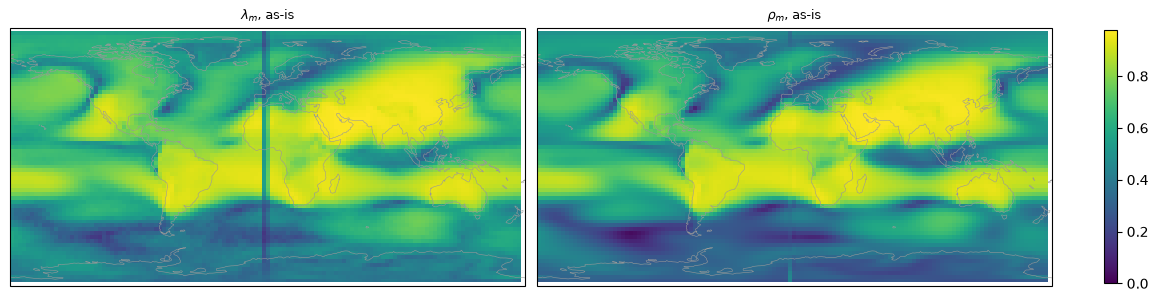

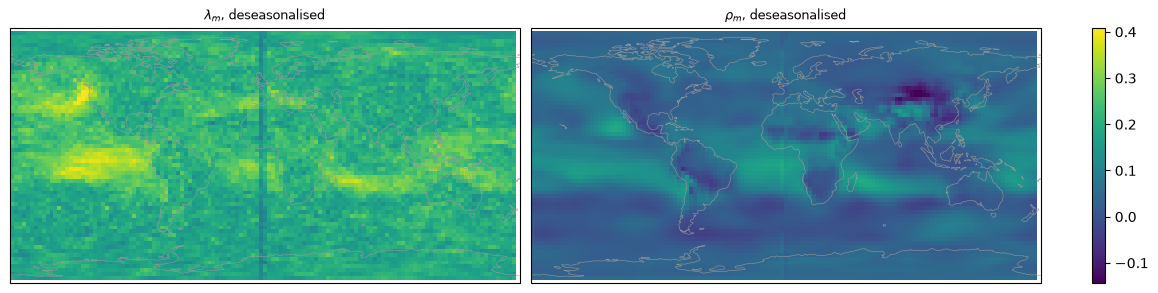

In [5]:
for t in TREATMENTS:
    a, b = LAM_M[t], RHO_M[t]
    nrm = Normalize(min(0.0, np.nanmin(a), np.nanmin(b)),
                    max(np.nanmax(a), np.nanmax(b)))
    fig, axs = plt.subplots(1, 2, figsize=(11.5, 3.1), layout="constrained",
                            subplot_kw={"projection": PROJ})
    panel(axs[0], a, "viridis", nrm, "$\\lambda_m$, %s" % t)
    h = panel(axs[1], b, "viridis", nrm, "$\\rho_m$, %s" % t)
    fig.colorbar(h, ax=axs, shrink=0.85, label="")
    plt.show()

## $\lambda_m$ against $\rho_m$, and the spread across members

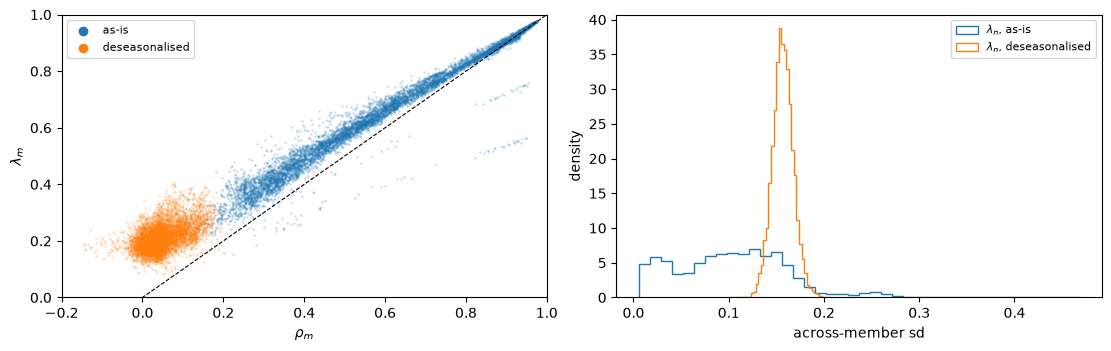

treatment         lam_n sd     r_n sd        I_n<0
as-is                0.104      0.104         2.0%
deseasonalised       0.157      0.110        27.7%


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.4), layout="constrained")

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[0].scatter(RHO_M[t].ravel(), LAM_M[t].ravel(), s=1, alpha=0.15, color=c, label=t)
axs[0].plot([-0.2, 1], [-0.2, 1], "k--", lw=0.8)
axs[0].set_xlabel("$\\rho_m$")
axs[0].set_ylabel("$\\lambda_m$")
axs[0].set_xlim(-0.2, 1)
axs[0].set_ylim(0, 1)
leg = axs[0].legend(fontsize=8, markerscale=6)
for lh in leg.legend_handles:
    lh.set_alpha(1)

for t, c in zip(TREATMENTS, ("tab:blue", "tab:orange")):
    axs[1].hist(LAM_N[t].std(axis=0).ravel(), bins=40, histtype="step",
                density=True, color=c, label="$\\lambda_n$, %s" % t)
axs[1].set_xlabel("across-member sd")
axs[1].set_ylabel("density")
axs[1].legend(fontsize=8)
plt.show()

print("%-15s %10s %10s %12s" % ("treatment", "lam_n sd", "r_n sd", "I_n<0"))
for t in TREATMENTS:
    print("%-15s %10.3f %10.3f %11.1f%%"
          % (t, LAM_N[t].std(axis=0).mean(), np.nanstd(R_N[t], axis=0).mean(),
             100 * np.mean(I_N[t] < 0)))